# Week 8 Final v2 — Frozen Week 7 Model + Live Pricing + Streamlit
**Week 7 is not modified.** Week 8 only loads the saved Week 7 Residual XGBoost model.

`Week 7 .pkl → latest JPM/VIX/10Y → live features → BSM → residual inference → ML-adjusted price → history → Streamlit auto-refresh`

Changes: no `Monte_Carlo_Price`, no residual target reconstruction, and no XGBoost retraining in Week 8.

In [15]:
!pip -q install yfinance xgboost joblib streamlit

In [16]:
import json, warnings, shutil
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf, joblib
from scipy.stats import norm
warnings.filterwarnings("ignore")
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR=Path("/content/drive/MyDrive/Chooser Option")
except Exception:
    PROJECT_DIR=Path.cwd()
WEEK8_DIR=PROJECT_DIR/"Week8"; WEEK8_DIR.mkdir(parents=True,exist_ok=True)
print(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Chooser Option


In [17]:
# Historical data: context only, not model training
DATA_CANDIDATES=[PROJECT_DIR/"week2_feature_dataset.csv",PROJECT_DIR/"week2_feature_dataset_pipeline.csv"]
DATA_PATH=next((p for p in DATA_CANDIDATES if p.exists()),None)
if DATA_PATH is None: raise FileNotFoundError("Week 2 feature dataset not found.")
df=pd.read_csv(DATA_PATH); df.columns=[str(c).strip() for c in df.columns]
if "Date" in df:
    df["Date"]=pd.to_datetime(df["Date"],errors="coerce"); df=df.sort_values("Date").reset_index(drop=True)
print(DATA_PATH,df.shape); display(df.head())

/content/drive/MyDrive/Chooser Option/week2_feature_dataset.csv (1701, 27)


,Date,Open,High,Low,Close,Adj Close,Volume,VIX,Treasury_10Y,Daily_Return,...,Dividend,Dividend_Growth,VIX_Return,VIX_JPM_Correlation_20D,Rate_Momentum_1D,Rate_Momentum_5D,Rate_Momentum_20D,Rate_Pct_Change_5D,Rate_Pct_Change_20D,Market_Sentiment_Index
0,2018-03-28,108.279999,109.169998,106.650002,108.000000,86.001305,19189300,22.870001,2.77,-0.001572,...,0.56,0.0,0.016444,-0.679450,-0.01,-0.12,-0.10,-0.041522,-0.034843,0.813435
1,2018-03-29,108.500000,110.779999,107.779999,109.970001,87.570045,13274600,19.969999,2.74,0.018241,...,0.56,0.0,-0.126804,-0.683304,-0.03,-0.09,-0.07,-0.031802,-0.024911,0.852869
2,2018-04-02,109.959999,110.730003,106.080002,107.849998,85.881882,18822500,23.620001,2.73,-0.019278,...,0.56,0.0,0.182774,-0.740853,-0.01,-0.09,-0.13,-0.031915,-0.045455,0.803236
3,2018-04-03,108.360001,109.500000,107.260002,109.330002,87.060417,14050700,21.100000,2.79,0.013723,...,0.56,0.0,-0.106689,-0.753804,0.06,-0.06,-0.09,-0.021053,-0.031250,0.837503
4,2018-04-04,107.099998,111.209999,107.019997,110.989998,88.382309,15302600,20.059999,2.79,0.015184,...,0.56,0.0,-0.049289,-0.755510,0.00,0.01,-0.09,0.003597,-0.031250,0.851645


In [18]:
# Contract + exact Week 7 model feature definitions
K=150.0; Q=0.0233; T1=0.5; T2=1.0; BEST_LAMBDA=0.95
rename={"Rolling Volatility":"Rolling_Vol_20D","VIX-JPM Correlation":"VIX_JPM_Correlation_20D","Sentiment Score":"Market_Sentiment_Index"}
for a,b in rename.items():
    if a in df and b not in df: df=df.rename(columns={a:b})
if "Moneyness" not in df: df["Moneyness"]=df.Close/K
if "Log_Moneyness" not in df: df["Log_Moneyness"]=np.log(df.Close/K)
if "Daily_Return" not in df: df["Daily_Return"]=df.Close.pct_change()
if "Log_Return" not in df: df["Log_Return"]=np.log(df.Close/df.Close.shift(1))
if "VIX_Return" not in df: df["VIX_Return"]=df.VIX.pct_change()
for w in [5,20,60]:
    c=f"Rolling_Vol_{w}D"
    if c not in df: df[c]=df.Daily_Return.rolling(w).std()*np.sqrt(252)
df["VIX_Decimal"]=df.VIX/100
if "Volatility_Spread" not in df: df["Volatility_Spread"]=df.VIX_Decimal-df.Rolling_Vol_20D
if "Volatility_Ratio" not in df: df["Volatility_Ratio"]=df.VIX_Decimal/df.Rolling_Vol_20D.replace(0,np.nan)
for w in [5,20]:
    if f"Rate_Momentum_{w}D" not in df: df[f"Rate_Momentum_{w}D"]=df.Treasury_10Y-df.Treasury_10Y.shift(w)
    if f"Rate_Pct_Change_{w}D" not in df: df[f"Rate_Pct_Change_{w}D"]=df.Treasury_10Y.pct_change(w)
    if f"Price_Momentum_{w}D" not in df: df[f"Price_Momentum_{w}D"]=df.Close.pct_change(w)
if "VIX_JPM_Correlation_20D" not in df: df["VIX_JPM_Correlation_20D"]=df.Daily_Return.rolling(20).corr(df.VIX_Return)
VIX_TRAIN_MIN,VIX_TRAIN_MAX=float(df.VIX.quantile(.01)),float(df.VIX.quantile(.99))
if "Market_Sentiment_Index" not in df: df["Market_Sentiment_Index"]=np.clip(1-(df.VIX-VIX_TRAIN_MIN)/(VIX_TRAIN_MAX-VIX_TRAIN_MIN),0,1)
if "Sentiment_x_Volatility" not in df: df["Sentiment_x_Volatility"]=df.Market_Sentiment_Index*df.Rolling_Vol_20D
MODEL_FEATURES=["Close","Moneyness","Log_Moneyness","Daily_Return","Log_Return","Rolling_Vol_5D","Rolling_Vol_20D","Rolling_Vol_60D","VIX","VIX_Return","Volatility_Spread","Volatility_Ratio","Treasury_10Y","Rate_Momentum_5D","Rate_Momentum_20D","Rate_Pct_Change_5D","Rate_Pct_Change_20D","VIX_JPM_Correlation_20D","Market_Sentiment_Index","Sentiment_x_Volatility","Price_Momentum_5D","Price_Momentum_20D","BSM_Analytical_Price"]
hist_features=[x for x in MODEL_FEATURES if x!="BSM_Analytical_Price"]
missing=[x for x in hist_features if x not in df]
if missing: raise ValueError(f"Missing historical features: {missing}")
print("OK:",len(MODEL_FEATURES),"model features; Monte_Carlo_Price not required.")

OK: 23 model features; Monte_Carlo_Price not required.


In [19]:
# Load frozen Week 7 model — NO FIT in Week 8
MODEL_CANDIDATES=[PROJECT_DIR/"Week7"/"week7_residual_xgb.pkl",PROJECT_DIR/"Week 7"/"week7_residual_xgb.pkl",PROJECT_DIR/"week7_residual_xgb.pkl"]
MODEL_PATH=next((p for p in MODEL_CANDIDATES if p.exists()),None)
if MODEL_PATH is None:
    print("Searched:",*[str(p) for p in MODEL_CANDIDATES],sep="\n - ")
    raise FileNotFoundError("week7_residual_xgb.pkl not found. Export it once from Week 7.")
residual_xgb=joblib.load(MODEL_PATH)
print("Loaded frozen Week 7 model:",MODEL_PATH)

Loaded frozen Week 7 model: /content/drive/MyDrive/Chooser Option/Week7/week7_residual_xgb.pkl


In [20]:
def simple_chooser_bsm(S0,K,r,q,sigma,T1,T2):
    d1=(np.log(S0/K)+(r-q+.5*sigma**2)*T2)/(sigma*np.sqrt(T2)); d2=d1-sigma*np.sqrt(T2)
    call=S0*np.exp(-q*T2)*norm.cdf(d1)-K*np.exp(-r*T2)*norm.cdf(d2)
    Ks=K*np.exp(-(r-q)*(T2-T1))
    e1=(np.log(S0/Ks)+(r-q+.5*sigma**2)*T1)/(sigma*np.sqrt(T1)); e2=e1-sigma*np.sqrt(T1)
    return float(call+Ks*np.exp(-r*T1)*norm.cdf(-e2)-S0*np.exp(-q*T1)*norm.cdf(-e1))

def yf_close(t,p,i):
    x=yf.download(t,period=p,interval=i,auto_adjust=True,progress=False,threads=False)
    if x.empty: raise RuntimeError(f"No data: {t}")
    s=x["Close"]
    if isinstance(s,pd.DataFrame): s=s.iloc[:,0]
    return pd.to_numeric(s,errors="coerce").dropna()

def download_markets(period="5d",interval="5m"):
    daily=pd.concat([yf_close("JPM","1y","1d").rename("Close"),yf_close("^VIX","1y","1d").rename("VIX"),yf_close("^TNX","1y","1d").rename("Treasury_10Y")],axis=1).dropna()
    intra=pd.concat([yf_close("JPM",period,interval).rename("Close"),yf_close("^VIX",period,interval).rename("VIX"),yf_close("^TNX",period,interval).rename("Treasury_10Y")],axis=1).dropna()
    intra.index=pd.to_datetime(intra.index)
    if len(daily)<65 or intra.empty: raise RuntimeError("Insufficient aligned market data.")
    return daily,intra

In [21]:
def live_features(d,S,V,R):
    idx=pd.Timestamp.now(tz=d.index.tz) if getattr(d.index,"tz",None) else pd.Timestamp.now()
    x=pd.concat([d,pd.DataFrame({"Close":[S],"VIX":[V],"Treasury_10Y":[R]},index=[idx])])
    c,v,r=x.Close,x.VIX,x.Treasury_10Y; ret=c.pct_change(); lr=np.log(c/c.shift(1)); vr=v.pct_change()
    f={"Close":float(c.iloc[-1]),"Moneyness":float(c.iloc[-1]/K),"Log_Moneyness":float(np.log(c.iloc[-1]/K)),"Daily_Return":float(ret.iloc[-1]),"Log_Return":float(lr.iloc[-1]),"Rolling_Vol_5D":float(ret.rolling(5).std().iloc[-1]*np.sqrt(252)),"Rolling_Vol_20D":float(ret.rolling(20).std().iloc[-1]*np.sqrt(252)),"Rolling_Vol_60D":float(ret.rolling(60).std().iloc[-1]*np.sqrt(252)),"VIX":float(v.iloc[-1]),"VIX_Return":float(vr.iloc[-1]),"Treasury_10Y":float(r.iloc[-1]),"Rate_Momentum_5D":float(r.iloc[-1]-r.iloc[-6]),"Rate_Momentum_20D":float(r.iloc[-1]-r.iloc[-21]),"Rate_Pct_Change_5D":float(r.pct_change(5).iloc[-1]),"Rate_Pct_Change_20D":float(r.pct_change(20).iloc[-1]),"VIX_JPM_Correlation_20D":float(ret.rolling(20).corr(vr).iloc[-1]),"Price_Momentum_5D":float(c.pct_change(5).iloc[-1]),"Price_Momentum_20D":float(c.pct_change(20).iloc[-1])}
    f["VIX_Decimal"]=f["VIX"]/100; f["Volatility_Spread"]=f["VIX_Decimal"]-f["Rolling_Vol_20D"]; f["Volatility_Ratio"]=f["VIX_Decimal"]/max(f["Rolling_Vol_20D"],1e-8)
    f["Market_Sentiment_Index"]=float(np.clip(1-(f["VIX"]-VIX_TRAIN_MIN)/max(VIX_TRAIN_MAX-VIX_TRAIN_MIN,1e-8),0,1))
    f["Sentiment_x_Volatility"]=f["Market_Sentiment_Index"]*f["Rolling_Vol_20D"]
    f["BSM_Analytical_Price"]=simple_chooser_bsm(f["Close"],K,f["Treasury_10Y"]/100,Q,max(f["Rolling_Vol_60D"],1e-4),T1,T2)
    return f

def build_pricing_series(period="5d",interval="5m",max_points=500):
    daily,intra=download_markets(period,interval); rows=[]
    for ts,row in intra.tail(max_points).iterrows():
        f=live_features(daily,float(row.Close),float(row.VIX),float(row.Treasury_10Y))
        X=pd.DataFrame([{c:f[c] for c in MODEL_FEATURES}])
        resid=float(residual_xgb.predict(X)[0]); corr=BEST_LAMBDA*resid
        rows.append({"Timestamp":ts,"JPM":f["Close"],"VIX":f["VIX"],"Treasury_10Y":f["Treasury_10Y"],"BSM_Price":f["BSM_Analytical_Price"],"Predicted_Residual":resid,"ML_Correction":corr,"ML_Adjusted_Price":f["BSM_Analytical_Price"]+corr})
    return pd.DataFrame(rows).sort_values("Timestamp").reset_index(drop=True)

pricing_series=build_pricing_series()
display(pricing_series.tail(10))

,Timestamp,JPM,VIX,Treasury_10Y,BSM_Price,Predicted_Residual,ML_Correction,ML_Adjusted_Price
320,2026-09-18 18:10:00+00:00,347.579987,15.24,5.000,196.890585,-0.288705,-0.274270,196.616315
321,2026-09-18 18:15:00+00:00,347.959991,15.19,5.000,197.261838,-0.291544,-0.276967,196.984871
322,2026-09-18 18:20:00+00:00,348.100006,15.17,5.000,197.398628,-0.292014,-0.277413,197.121214
323,2026-09-18 18:25:00+00:00,348.390015,15.13,5.000,197.681957,-0.292869,-0.278226,197.403731
324,2026-09-18 18:30:00+00:00,348.250000,15.11,4.998,197.542314,-0.292869,-0.278226,197.264088
325,2026-09-18 18:35:00+00:00,347.769989,15.08,4.998,197.073358,-0.292869,-0.278226,196.795132
326,2026-09-18 18:40:00+00:00,347.720001,15.04,5.002,197.030229,-0.290030,-0.275528,196.754700
327,2026-09-18 18:45:00+00:00,348.350006,14.97,5.000,197.642870,-0.292426,-0.277804,197.365066
328,2026-09-18 18:50:00+00:00,348.494995,14.96,4.998,197.781666,-0.292426,-0.277804,197.503862
329,2026-09-18 18:55:00+00:00,348.579987,14.99,4.998,197.864700,-0.292426,-0.277804,197.586896


,Timestamp,JPM,VIX,Treasury_10Y,BSM_Price,Predicted_Residual,ML_Correction,ML_Adjusted_Price
329,2026-09-18 18:55:00+00:00,348.579987,14.99,4.998,197.8647,-0.292426,-0.277804,197.586896


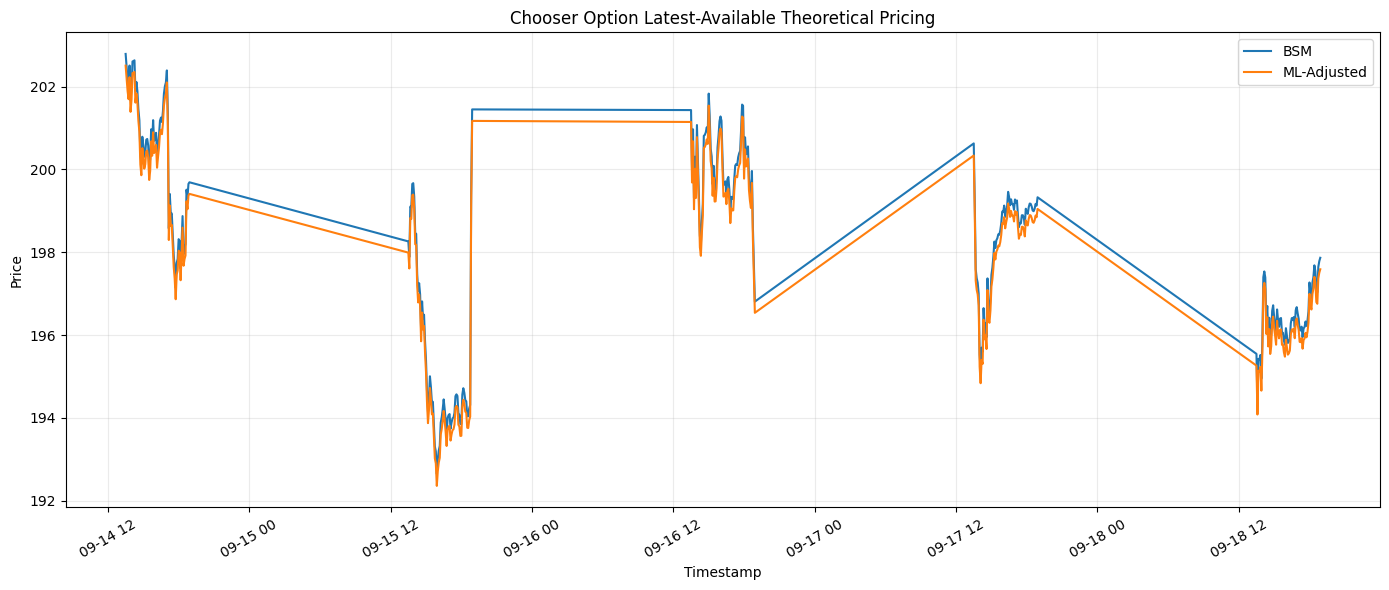

In [22]:
latest=pricing_series.iloc[-1]
display(pd.DataFrame([latest]))
plt.figure(figsize=(14,6))
plt.plot(pricing_series.Timestamp,pricing_series.BSM_Price,label="BSM")
plt.plot(pricing_series.Timestamp,pricing_series.ML_Adjusted_Price,label="ML-Adjusted")
plt.title("Chooser Option Latest-Available Theoretical Pricing")
plt.xlabel("Timestamp"); plt.ylabel("Price"); plt.legend(); plt.grid(alpha=.25); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [23]:
# Persist latest unique market timestamp
HISTORY_PATH=WEEK8_DIR/"live_price_history.csv"; latest_row=pricing_series.tail(1)
if HISTORY_PATH.exists():
    history=pd.concat([pd.read_csv(HISTORY_PATH),latest_row],ignore_index=True).drop_duplicates("Timestamp",keep="last")
else: history=latest_row.copy()
history.to_csv(HISTORY_PATH,index=False)
print("Saved:",HISTORY_PATH,"rows:",len(history)); display(history.tail())

Saved: /content/drive/MyDrive/Chooser Option/Week8/live_price_history.csv rows: 2


,Timestamp,JPM,VIX,Treasury_10Y,BSM_Price,Predicted_Residual,ML_Correction,ML_Adjusted_Price
0,2026-09-18 18:55:00+00:00,348.579987,14.99,4.998,197.8647,-0.292426,-0.277804,197.586896
1,2026-09-18 18:55:00+00:00,348.579987,14.99,4.998,197.8647,-0.292426,-0.277804,197.586896


## Streamlit export
The following cell creates a self-contained Streamlit project. It copies the **existing Week 7 model**; it does not train a new one.

In [24]:
APP_DIR=WEEK8_DIR/"streamlit_app"; (APP_DIR/"models").mkdir(parents=True,exist_ok=True); (APP_DIR/"data").mkdir(exist_ok=True)
shutil.copy2(MODEL_PATH,APP_DIR/"models"/"week7_residual_xgb.pkl")
cfg={"K":K,"Q":Q,"T1":T1,"T2":T2,"BEST_LAMBDA":BEST_LAMBDA,"MODEL_FEATURES":MODEL_FEATURES,"VIX_TRAIN_MIN":VIX_TRAIN_MIN,"VIX_TRAIN_MAX":VIX_TRAIN_MAX}
(APP_DIR/"models"/"week8_config.json").write_text(json.dumps(cfg,indent=2),encoding="utf-8")
print("Model/config exported. The next cell writes the Streamlit files.")

Model/config exported. The next cell writes the Streamlit files.


In [25]:
# Write a standalone pricing engine from this notebook
engine = """import json
from pathlib import Path
import numpy as np, pandas as pd, yfinance as yf, joblib
from scipy.stats import norm
ROOT=Path(__file__).parent
cfg=json.loads((ROOT/'models/week8_config.json').read_text())
model=joblib.load(ROOT/'models/week7_residual_xgb.pkl')
def bsm(S,K,r,q,s,T1,T2):
 d1=(np.log(S/K)+(r-q+.5*s*s)*T2)/(s*np.sqrt(T2)); d2=d1-s*np.sqrt(T2); call=S*np.exp(-q*T2)*norm.cdf(d1)-K*np.exp(-r*T2)*norm.cdf(d2); Ks=K*np.exp(-(r-q)*(T2-T1)); e1=(np.log(S/Ks)+(r-q+.5*s*s)*T1)/(s*np.sqrt(T1)); e2=e1-s*np.sqrt(T1); return float(call+Ks*np.exp(-r*T1)*norm.cdf(-e2)-S*np.exp(-q*T1)*norm.cdf(-e1))
def dl(t,p,i):
 x=yf.download(t,period=p,interval=i,auto_adjust=True,progress=False,threads=False); s=x['Close']; s=s.iloc[:,0] if isinstance(s,pd.DataFrame) else s; return pd.to_numeric(s,errors='coerce').dropna()
def prices(period='5d',interval='5m'):
 d=pd.concat([dl('JPM','1y','1d').rename('Close'),dl('^VIX','1y','1d').rename('VIX'),dl('^TNX','1y','1d').rename('Treasury_10Y')],axis=1).dropna(); z=pd.concat([dl('JPM',period,interval).rename('Close'),dl('^VIX',period,interval).rename('VIX'),dl('^TNX',period,interval).rename('Treasury_10Y')],axis=1).dropna(); rows=[]
 for ts,row in z.tail(500).iterrows():
  idx=pd.Timestamp.now(tz=d.index.tz) if getattr(d.index,'tz',None) else pd.Timestamp.now(); x=pd.concat([d,pd.DataFrame({'Close':[float(row.Close)],'VIX':[float(row.VIX)],'Treasury_10Y':[float(row.Treasury_10Y)]},index=[idx])]); c,v,r=x.Close,x.VIX,x.Treasury_10Y; ret=c.pct_change(); lr=np.log(c/c.shift(1)); vr=v.pct_change(); K=float(cfg['K'])
  f={'Close':float(c.iloc[-1]),'Moneyness':float(c.iloc[-1]/K),'Log_Moneyness':float(np.log(c.iloc[-1]/K)),'Daily_Return':float(ret.iloc[-1]),'Log_Return':float(lr.iloc[-1]),'Rolling_Vol_5D':float(ret.rolling(5).std().iloc[-1]*np.sqrt(252)),'Rolling_Vol_20D':float(ret.rolling(20).std().iloc[-1]*np.sqrt(252)),'Rolling_Vol_60D':float(ret.rolling(60).std().iloc[-1]*np.sqrt(252)),'VIX':float(v.iloc[-1]),'VIX_Return':float(vr.iloc[-1]),'Treasury_10Y':float(r.iloc[-1]),'Rate_Momentum_5D':float(r.iloc[-1]-r.iloc[-6]),'Rate_Momentum_20D':float(r.iloc[-1]-r.iloc[-21]),'Rate_Pct_Change_5D':float(r.pct_change(5).iloc[-1]),'Rate_Pct_Change_20D':float(r.pct_change(20).iloc[-1]),'VIX_JPM_Correlation_20D':float(ret.rolling(20).corr(vr).iloc[-1]),'Price_Momentum_5D':float(c.pct_change(5).iloc[-1]),'Price_Momentum_20D':float(c.pct_change(20).iloc[-1])}
  f['VIX_Decimal']=f['VIX']/100; f['Volatility_Spread']=f['VIX_Decimal']-f['Rolling_Vol_20D']; f['Volatility_Ratio']=f['VIX_Decimal']/max(f['Rolling_Vol_20D'],1e-8); lo,hi=cfg['VIX_TRAIN_MIN'],cfg['VIX_TRAIN_MAX']; f['Market_Sentiment_Index']=float(np.clip(1-(f['VIX']-lo)/max(hi-lo,1e-8),0,1)); f['Sentiment_x_Volatility']=f['Market_Sentiment_Index']*f['Rolling_Vol_20D']; f['BSM_Analytical_Price']=bsm(f['Close'],K,f['Treasury_10Y']/100,cfg['Q'],max(f['Rolling_Vol_60D'],1e-4),cfg['T1'],cfg['T2']); resid=float(model.predict(pd.DataFrame([{q:f[q] for q in cfg['MODEL_FEATURES']}]))[0]); corr=cfg['BEST_LAMBDA']*resid; rows.append({'Timestamp':ts,'JPM':f['Close'],'VIX':f['VIX'],'BSM_Price':f['BSM_Analytical_Price'],'ML_Correction':corr,'ML_Adjusted_Price':f['BSM_Analytical_Price']+corr})
 return pd.DataFrame(rows)
"""
(APP_DIR/"pricing_engine.py").write_text(engine,encoding="utf-8")

app="""from pathlib import Path
import pandas as pd, streamlit as st
from pricing_engine import prices
ROOT=Path(__file__).parent; H=ROOT/'data/live_price_history.csv'
st.set_page_config(page_title='Chooser Live Pricing',layout='wide'); st.title('Chooser Option Live Pricing')
with st.sidebar:
 interval=st.selectbox('Market interval',['5m','15m','30m','60m']); period=st.selectbox('History',['1d','5d'],index=1); live=st.toggle('LIVE — refresh every 5 minutes',True)
def render():
 try: s=prices(period,interval)
 except Exception as e: st.error(str(e)); return
 last=s.iloc[-1]; old=pd.read_csv(H) if H.exists() else pd.DataFrame(); out=pd.concat([old,pd.DataFrame([last.to_dict()])],ignore_index=True).drop_duplicates('Timestamp',keep='last'); H.parent.mkdir(exist_ok=True); out.to_csv(H,index=False)
 a,b,c,d=st.columns(4); a.metric('JPM',f'${last.JPM:.2f}'); b.metric('VIX',f'{last.VIX:.2f}'); c.metric('BSM',f'${last.BSM_Price:.4f}'); d.metric('ML-adjusted',f'${last.ML_Adjusted_Price:.4f}')
 st.line_chart(s.set_index('Timestamp')[['BSM_Price','ML_Adjusted_Price']],height=400); st.line_chart(s.set_index('Timestamp')[['ML_Correction']],height=220); st.caption(f'Last market timestamp: {last.Timestamp}')
if live:
 @st.fragment(run_every=300)
 def live_view(): render()
 live_view()
else:
 if st.button('Refresh now'): st.cache_data.clear()
 render()
"""
(APP_DIR/"streamlit_app.py").write_text(app,encoding="utf-8")
(APP_DIR/"requirements.txt").write_text("streamlit>=1.37\\nyfinance>=0.2.54\\npandas>=2.1\\nnumpy>=1.26\\nscipy>=1.11\\nxgboost>=2.0\\njoblib>=1.3\\n",encoding="utf-8")
print("Generated:",APP_DIR)

Generated: /content/drive/MyDrive/Chooser Option/Week8/streamlit_app


## Start / Stop
After the notebook succeeds, run `streamlit run streamlit_app.py` inside `Week8/streamlit_app`.

- **LIVE ON:** automatically refreshes pricing every 5 minutes while the Streamlit session is active.
- **LIVE OFF:** stops automatic refresh.
- Stop the Streamlit process to shut down the server.
- True unattended 24/7 collection after the browser closes requires a separate background collector + persistent storage; that can be a later production extension.

In [26]:
%cd "/content/drive/MyDrive/Chooser Option/Week8/streamlit_app"

/content/drive/MyDrive/Chooser Option/Week8/streamlit_app


In [27]:
!ls

data  models  pricing_engine.py  requirements.txt  streamlit_app.py


In [36]:
!streamlit run streamlit_app.py \
    --server.port 8501 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false



2026-09-19 07:45:06.168 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.78.200:8501

  Stopping...


In [29]:
!pip -q install pyngrok

In [35]:
from google.colab import output

url = output.eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-use1d0-3s9k7oqm79f1t-d.us-east1-0.prod.colab.dev
